In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 设置 DataFrame 表格打印显示格式
pd.set_option('display.max_columns', None)  # 设置最大显示列数：None代表全部列都显示
pd.set_option('display.width', 2000)        # 设置输出表格宽度，数值调大，单位字符
pd.set_option('display.max_colwidth', 30)   # 每列最大字符长度

In [26]:
""" 加载训练数据 """
train = pd.read_csv("8.used_car_train.csv", sep=r"\s+") # 数据间使用的是空格来分隔
print(train.shape)
print(train.columns.tolist())
train.info()

(150000, 31)
['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode', 'seller', 'offerType', 'creatDate', 'price', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 31 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SaleID             150000 non-null  int64  
 1   name               150000 non-null  int64  
 2   regDate            150000 non-null  int64  
 3   model              150000 non-null  float64
 4   brand              150000 non-null  float64
 5   bodyType           150000 non-null  float64
 6   fuelType           150000 non-null  float64
 7   gearbox            150000 non-null  object 
 8   power              150000 non-null  object 
 9   kilometer          150000 non-null  o

![](8.二手车价格预测特征说明.png)

In [27]:
""" 打开 csv 文件，发现特征 notRepairedDamage 的值有字符 -, 先处理 """
print(train['notRepairedDamage'].unique())

train['notRepairedDamage'] = pd.to_numeric(train['notRepairedDamage'], errors='coerce')
print(train['notRepairedDamage'].unique())

['0.0' '-' '1.0' ... '1882' '7753' '2159']
[0.000e+00       nan 1.000e+00 ... 1.882e+03 7.753e+03 2.159e+03]


In [28]:
""" 查看缺失值 """
missing_stats = train.isna().sum()
missing_percent = train.isna().sum() / len(train)
missing_df = pd.DataFrame({"缺失数量":missing_stats, "缺失占比":missing_percent})
print(missing_df[missing_df["缺失数量"]>0])

                    缺失数量      缺失占比
notRepairedDamage  17558  0.117053
v_12                1469  0.009793
v_13                3583  0.023887
v_14               14116  0.094107


In [29]:
""" 处理缺失值 """
# 1. notRepairedDamage：把 '-' 替换成 NaN（前面已经做过了），再填充 -1 代表未知
train['notRepairedDamage'] = train['notRepairedDamage'].fillna(-1)

# 2. v_12、v_13、v_14：连续特征，统一用中位数填充（抗异常值）
for col in ['v_12', 'v_13', 'v_14']:
    train[col] = train[col].fillna(train[col].median())

# 3. 验证：确认没有任何缺失了
print(train.isna().sum().sum())

0


In [30]:
""" 类型转换 """
objectToInt = ['gearbox', 'power', 'kilometer']
for feature in objectToInt:
    train[feature] = pd.to_numeric(train[feature], errors='coerce')

print(train[objectToInt].dtypes)
print(train[objectToInt].isna().sum())  # 看 power/kilometer 有没有转失败产生NaN

gearbox      float64
power        float64
kilometer    float64
dtype: object
gearbox      1387
power        1188
kilometer    4191
dtype: int64


In [31]:
""" 填充缺失值 """
train['gearbox'] = train['gearbox'].fillna(-1)
train['power'] = train['power'].fillna(train['power'].median())
train['kilometer'] = train['kilometer'].fillna(train['kilometer'].median())

# 再次校验缺失
print(train.isna().sum().sum())

0


In [32]:
""" 处理两个日期特征 """
from datetime import datetime

def parse_date_safe(num):
    try:
        s = str(int(num))
        return datetime.strptime(s, "%Y%m%d")
    except:
        return np.nan # 非法日期直接返回空

# 生成日期
train['reg_datetime'] = train['regDate'].apply(parse_date_safe)
train['create_datetime'] = train['creatDate'].apply(parse_date_safe)

# 计算车龄（年），存在 NaN 的地方车龄自动为 NaN
train['car_age'] = (train['create_datetime'] - train['reg_datetime']).dt.days / 365

# 查看有多少条非法日期样本
print("regDate非法日期数量：", train['reg_datetime'].isna().sum())
print("creatDate非法日期数量：", train['create_datetime'].isna().sum())
print("car_age缺失数量：", train['car_age'].isna().sum())

regDate非法日期数量： 11347
creatDate非法日期数量： 14116
car_age缺失数量： 20290


In [33]:
""" 处理缺失值 """
train['car_age'] = train['car_age'].fillna(train['car_age'].median())

# 删除原始日期字段，不再使用
train = train.drop(['regDate','creatDate','reg_datetime','create_datetime'], axis=1)

# 校验
print(train['car_age'].isna().sum())

0


In [34]:
""" 去掉无用的特征 """
train = train.drop(columns=['SaleID', 'name'])

In [35]:
""" 划分 """
from sklearn.model_selection import train_test_split

X = train.drop('price', axis=1)
y = train['price']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("训练集特征形状：", X_train.shape)
print("验证集特征形状：", X_val.shape)

训练集特征形状： (120000, 27)
验证集特征形状： (30000, 27)


In [36]:
""" 随机森林 """
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_lr = mean_absolute_error(y_val, y_pred_rf)
r2_lr = r2_score(y_val, y_pred_rf)

print("===== 随机森林回归评估结果 =====")
print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE:  {mae_lr:.2f}")
print(f"R²:   {r2_lr:.4f}")

===== 随机森林回归评估结果 =====
RMSE: 1435.07
MAE:  632.41
R²:   0.9622


✅ 效果很好啊！

- $R^2=0.9622$：模型可以解释 96.22% 的二手车价格波动；
- $MAE=632.41$：平均预测价格和真实价格相差约 632 元；
- $RMSE=1435.07$：对个别预测偏差很大的样本惩罚更强，最大误差会更高。

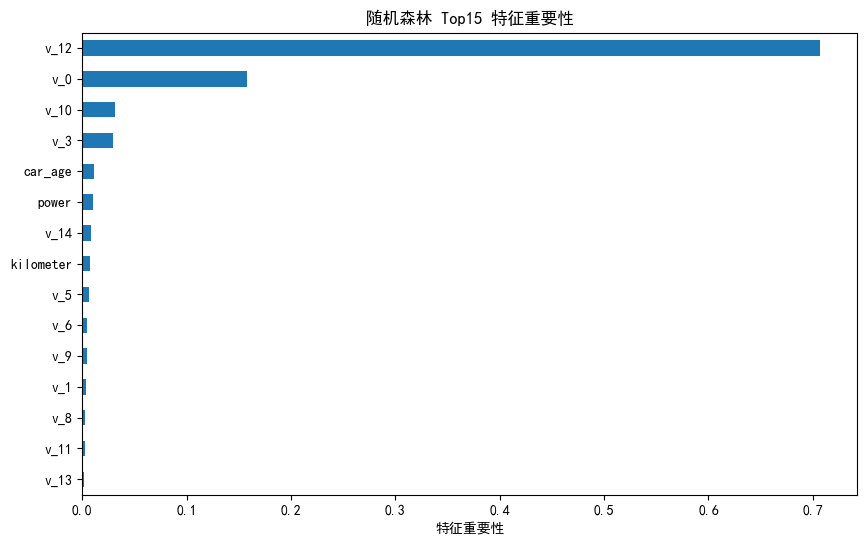

In [37]:
""" 随机森林特征重要性 """
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh')
plt.title("随机森林 Top15 特征重要性")
plt.xlabel("特征重要性")
plt.gca().invert_yaxis()
plt.show()

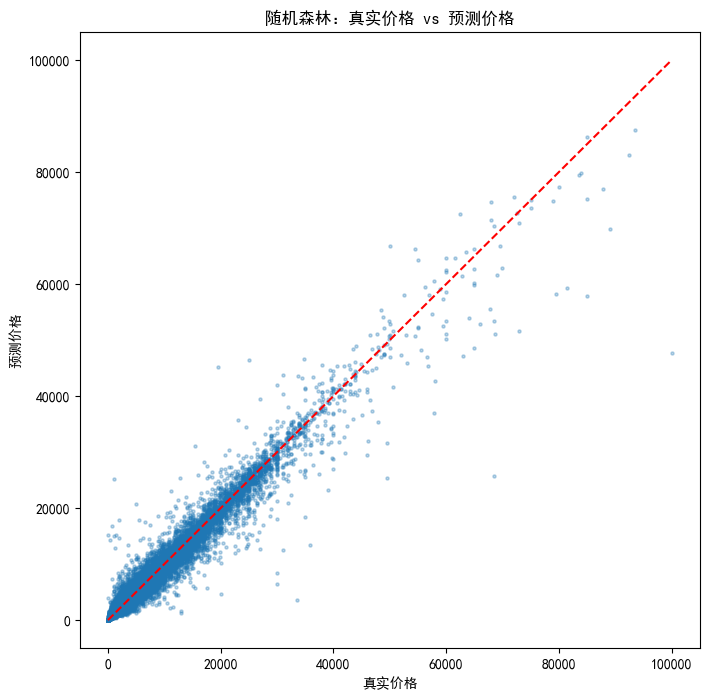

In [38]:
""" 随机森林预测结果 """
plt.figure(figsize=(8,8))
plt.scatter(y_val, y_pred_rf, alpha=0.3, s=5)

# 理想预测线：真实 = 预测
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("真实价格")
plt.ylabel("预测价格")
plt.title("随机森林：真实价格 vs 预测价格")
plt.show()

#### 散点图结果解读

整体趋势：

- 低价区间（0~40000）：样本大量聚集，点紧紧贴住红色虚线，预测效果很好；
- 高价区间（>40000）：样本变少，点开始散开，**模型倾向于低估高价二手车**，很多真实高价车，预测价格明显低于真实值。

In [39]:
""" LightGBM """
import lightgbm as lgb

lgb = lgb.LGBMRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict(X_val)

rmse_lgb = np.sqrt(mean_squared_error(y_val, y_pred_lgb))
mae_lgb = mean_absolute_error(y_val, y_pred_lgb)
r2_lgb = r2_score(y_val, y_pred_lgb)

print("==== LightGBM 评估结果 ====")
print(f"RMSE: {rmse_lgb:.2f}")
print(f"MAE:  {mae_lgb:.2f}")
print(f"R²:   {r2_lgb:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6191
[LightGBM] [Info] Number of data points in the train set: 120000, number of used features: 27
[LightGBM] [Info] Start training from score 5639.236839
==== LightGBM 评估结果 ====
RMSE: 1374.24
MAE:  668.21
R²:   0.9653


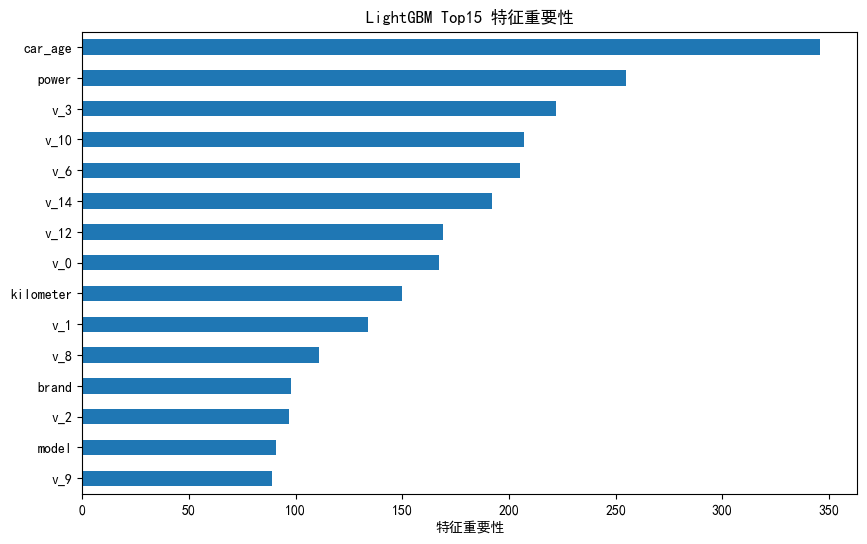

In [40]:
""" LightGBM 特征重要性 """
feature_importance = pd.Series(
    lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh')
plt.title("LightGBM Top15 特征重要性")
plt.xlabel("特征重要性")
plt.gca().invert_yaxis()
plt.show()

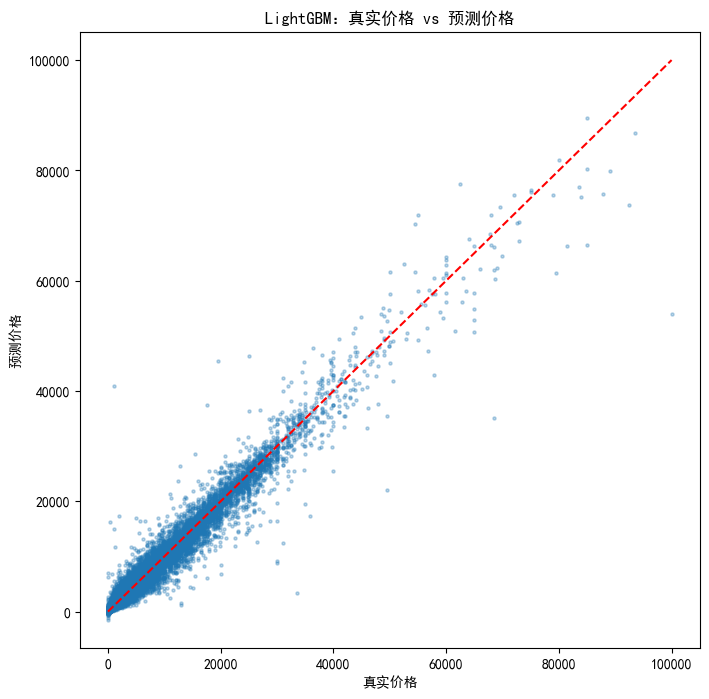

In [41]:
""" LightGBM 预测结果 """
plt.figure(figsize=(8,8))
plt.scatter(y_val, y_pred_lgb, alpha=0.3, s=5)

# 理想预测线：真实 = 预测
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("真实价格")
plt.ylabel("预测价格")
plt.title("LightGBM：真实价格 vs 预测价格")
plt.show()

#### 指标解读

1. LightGBM 的 $R^2$ 更高，$RMSE$ 更小，整体预测误差更小，总体性能优于随机森林；
2. $MAE$ 略高于随机森林：说明 LightGBM 对**大部分普通样本**平均误差稍大，但对少数大偏差样本（高价车）的抑制更好（$RMSE$ 更低）；
3. 两张散点图对比：LightGBM 高价区域的离散程度相比随机森林有轻微改善，但依然存在高价车低估的现象。

#### 特征重要性巨大差异

- **随机森林**：极度依赖`v_12`，单一特征占比 70% 以上，业务特征（car_age、power）权重很低；
- **LightGBM**：`car_age（车龄）`变成最重要特征，其次是 power，脱敏 v 系列特征权重被分散，符合我们二手车业务常识。

In [42]:
""" LightGBM 错误样本分析 """
res_df = X_val.copy()
res_df["price_true"] = y_val
res_df["price_pred"] = y_pred_lgb
res_df["error"] = res_df["price_true"] - res_df["price_pred"]

# 真实价格高，预测偏低：误差>0，取前20个低估最严重样本
under_pred = res_df.sort_values("error", ascending=False).head(20)
print("===== 被严重低估的二手车样本 =====")
print(under_pred[["price_true","price_pred","error","car_age","power","kilometer"]])

===== 被严重低估的二手车样本 =====
        price_true    price_pred         error    car_age  power  kilometer
88326      99999.0  53949.851115  46049.148885  14.520548  114.0       15.0
112783     68530.0  35041.134055  33488.865945  16.747945  190.0       15.0
19083      33500.0   3353.919762  30146.080238   9.810959  150.0       15.0
55055      49500.0  21959.278278  27540.721722   3.493151    0.0        4.0
105451     30000.0   8773.564495  21226.435505  19.600000    0.0        6.0
22961      29900.0   9256.377785  20643.622215  19.715068  136.0        4.0
105007     92500.0  73702.229057  18797.770943   1.432877  600.0        1.0
112708     35840.0  17287.860623  18552.139377  19.019178  286.0       15.0
90978      31000.0  12453.386524  18546.613476  19.068493  231.0       15.0
132753     85000.0  66546.068309  18453.931691  21.731507  272.0        6.0
120445     79500.0  61417.724745  18082.275255  11.706849  360.0       12.5
10641      35000.0  19433.254230  15566.745770   3.356164  140.0

#### 低估样本分析总结

观察这批误差最大的样本，可以提炼出几个共性：

1. **一部分是车龄很大但价格依然很高的车**：比如车龄 14~23 年，真实售价还能到 3 万～10 万。
正常规律：车龄越大价格越低；但这批属于特殊车型（经典老车、收藏车），脱离普通二手车的价格规律。训练集中这类样本数量极少，模型没有学到这种特例，所以严重低估。
2. **部分样本 power=0**：马力字段缺失，丢失了关键信息，模型无法识别高性能车辆，造成低估。
3. **少量低里程、大马力的高价新车**：车龄很小、里程很低、马力极高，属于高端车，样本量偏少，模型对高价区间拟合不足。

In [43]:
""" XGBoost """
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_val)

rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print("===== XGBoost 评估结果 =====")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")
print(f"R²:   {r2_xgb:.4f}")

===== XGBoost 评估结果 =====
RMSE: 1462.61
MAE:  602.06
R²:   0.9607


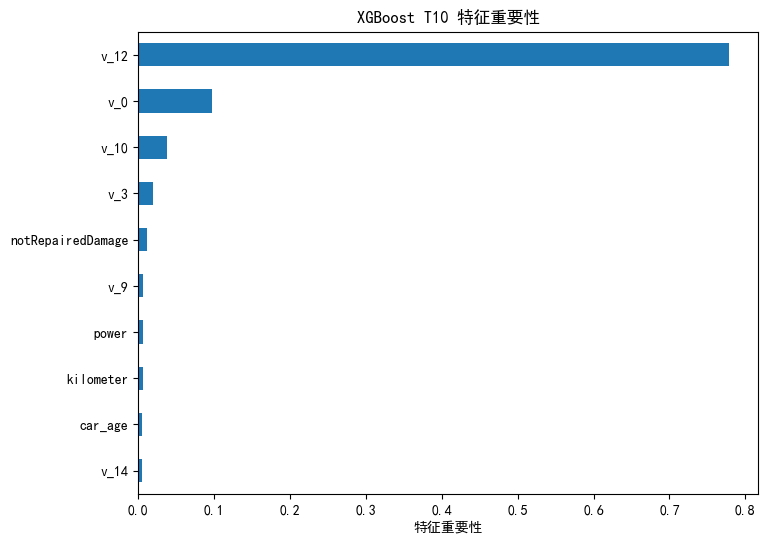

In [44]:
""" 查看特征重要性 """
feature_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
feature_importance.head(10).plot(kind="barh")
plt.title("XGBoost T10 特征重要性")
plt.xlabel("特征重要性")
plt.gca().invert_yaxis()
plt.show()

`v_12`权重接近 0.8，占据绝对主导，业务特征 car_age、power、kilometer 权重极低。

#### 三模型对比

| 模型       | RMSE    | MAE    | R²     | 特征重要性特点                          |
| -------- | ------- | ------ | ------ | -------------------------------- |
| 随机森林     | 1435.07 | 632.41 | 0.9622 | 高度依赖`v_12`，单特征权重 70%+            |
| LightGBM | 1374.24 | 668.21 | 0.9653 | 业务特征`car_age`、`power`权重最高，特征分配均衡 |
| XGBoost  | 1462.61 | 602.06 | 0.9607 | 同样极度依赖脱敏特征`v_12`，和随机森林特征偏好很像     |

##### 指标解读

1. **R²**：LightGBM > 随机森林 > XGBoost，LightGBM 对价格整体方差解释能力最强；
2. **RMSE**：LightGBM 最小，代表对**大误差样本**控制最好；XGBoost RMSE 最差，说明少数极端样本预测偏差更大；
3. **MAE**：XGBoost 最低，代表**绝大多数普通样本**的平均预测误差最小。

> 总结：XGBoost 在大部分常规二手车样本上预测更准，但遇到高价 / 特殊长尾样本时更容易出现巨大偏差；LightGBM 综合稳定性最好。

In [45]:
""" 预测集 """
test = pd.read_csv("8.used_car_test.csv", sep=r"\s+")
print(test.shape)
print(test.columns.tolist())
print(test.info())

(50000, 30)
['SaleID', 'name', 'regDate', 'model', 'brand', 'bodyType', 'fuelType', 'gearbox', 'power', 'kilometer', 'notRepairedDamage', 'regionCode', 'seller', 'offerType', 'creatDate', 'v_0', 'v_1', 'v_2', 'v_3', 'v_4', 'v_5', 'v_6', 'v_7', 'v_8', 'v_9', 'v_10', 'v_11', 'v_12', 'v_13', 'v_14']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SaleID             50000 non-null  int64  
 1   name               50000 non-null  int64  
 2   regDate            50000 non-null  int64  
 3   model              50000 non-null  float64
 4   brand              50000 non-null  int64  
 5   bodyType           50000 non-null  float64
 6   fuelType           50000 non-null  float64
 7   gearbox            50000 non-null  object 
 8   power              50000 non-null  object 
 9   kilometer          50000 non-null  object 
 10  notRepairedD

一样有缺失值，先处理，再预测，使用 LightGBM。

In [ ]:
""" 处理缺失值 """
test['notRepairedDamage'] = pd.to_numeric(test['notRepairedDamage'], errors="coerce")
test['notRepairedDamage'] = test['notRepairedDamage'].fillna(-1)

for col in ['v_12', 'v_13', 'v_14']:
    test[col] = test[col].fillna(test[col].median())

objectToInt = ['gearbox', 'power', 'kilometer']
for feature in objectToInt:
    test[feature] = pd.to_numeric(test[feature], errors="coerce")

test['gearbox'] = test['gearbox'].fillna(-1)
test['power'] = test['power'].fillna(test['power'].median())
test['kilometer'] = test['kilometer'].fillna(test['kilometer'].median())

test['regDate'] = test['regDate'].apply(parse_date_safe)
test['creatDate'] = test['creatDate'].apply(parse_date_safe)
test['car_age'] = (test['creatDate'] - test['regDate']).dt.days / 365
test['car_age'] = test['car_age'].fillna(test['car_age'].median())

test_id = test["SaleID"].copy() # 先保存 ID, 后面要填入 8.result.csv 中
drop_cols = ['SaleID', 'name', 'regDate', 'creatDate']
test = test.drop(columns=drop_cols)

In [48]:
""" 预测并将结果填入 8.used_car_sample.csv 中 """
y_pred = lgb.predict(test)

result = pd.DataFrame({
    "SaleID": test_id,
    "price": y_pred
})

result.to_csv("8.result.csv", index=False)